##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import identityTimeEmbedding, fourierTimeEmbedding, scalarConditionedNetworkMLP, rademacherProbe
from svipy.normflow import continuousNormFlow, timeConditionedField, normFlowPosterior

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


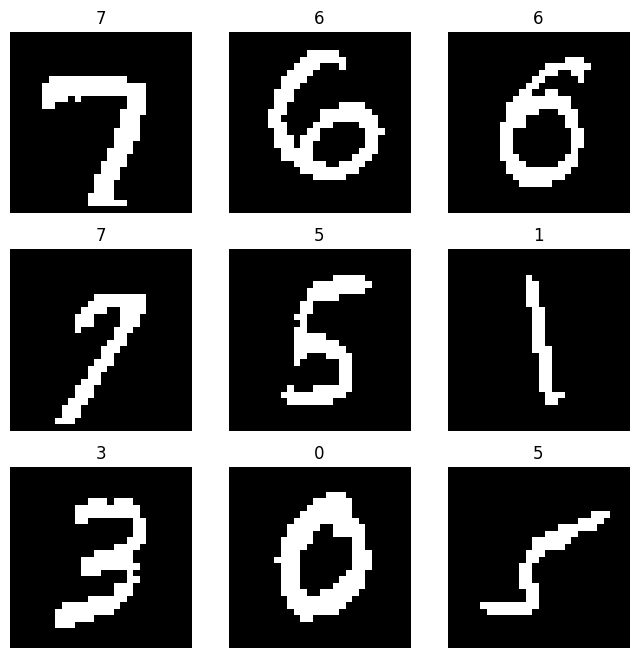

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### VAEs with norm flows

In [6]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Continuous normalized flows

In [12]:
in_dims = 28 * 28
hid_dims = 8

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 256),
                        nn.ReLU(),
                        nn.Linear(256, 256),
                        nn.ReLU(),
                        nn.Linear(256, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 256),
                        nn.ReLU(),
                        nn.Linear(256, 256),
                        nn.ReLU(),
                        nn.Linear(256, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

t_dims = 1
embed = identityTimeEmbedding()
tcn = scalarConditionedNetworkMLP(dims = [hid_dims, 64, 64], t_dim=t_dims, activation=torch.nn.Tanh())
sampler = rademacherProbe

tcf = timeConditionedField(tcn, embed, sampler)
post = normFlowPosterior(continuousNormFlow(tcf, direction='generate', odeMethod='rk4', odeOptions={'step_size': 0.05}))  # 
model_vae_cnf = variationalAutoencoder(encoder, decoder, posterior=post, kineticEnergyWeight=1.0e-3).to(device)

In [13]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_cnf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=10, minDelta=0.1, mode='min', restoreBestWeights=True)

In [14]:
%%time 
model_vae_cnf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_cnf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper
                       )

Epoch 1
-------------------------------
totalLoss: 193.302444 reconLoss: 201.082306 klLoss: -7.786214 fldj: 6.785842 kineticReg: 6.345142[12800/60000]
totalLoss: 142.062515 reconLoss: 169.743195 klLoss: -27.724703 fldj: 26.705421 kineticReg: 44.028992[25600/60000]
totalLoss: 82.022087 reconLoss: 152.809479 klLoss: -70.882477 fldj: 72.209511 kineticReg: 95.082642[38400/60000]
totalLoss: 132.757141 reconLoss: 149.749893 klLoss: -17.347466 fldj: 30.840199 kineticReg: 354.704590[51200/60000]
Validation Error: 119.232219
Epoch 2
-------------------------------
totalLoss: 123.123878 reconLoss: 134.332138 klLoss: -12.014975 fldj: 27.658527 kineticReg: 806.713501[12800/60000]
totalLoss: 115.759819 reconLoss: 122.931747 klLoss: -8.305490 fldj: 24.291061 kineticReg: 1133.558594[25600/60000]
totalLoss: 140.601685 reconLoss: 129.594986 klLoss: 9.480226 fldj: 17.088768 kineticReg: 1526.478882[38400/60000]
totalLoss: 131.601028 reconLoss: 120.796585 klLoss: 8.730262 fldj: 15.615003 kineticReg: 2074.

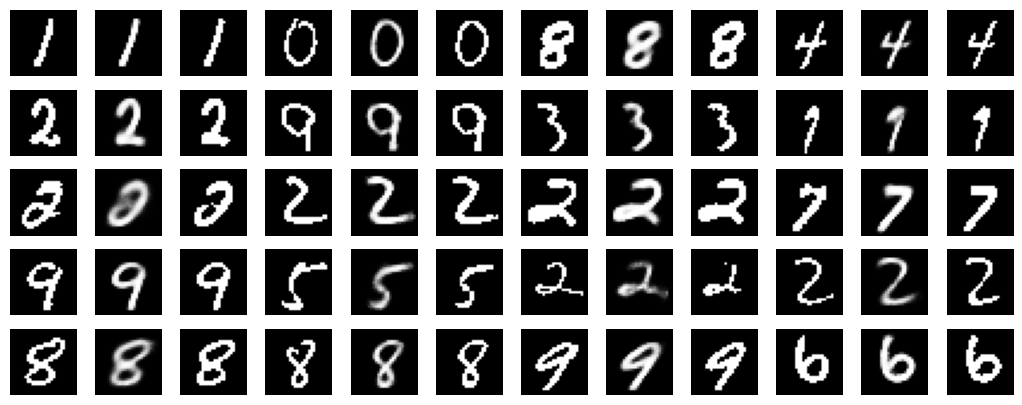

In [15]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_cnf.eval()

idxs = []

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        idxs.append(sidx)
        
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_cnf.deterministicRecon(trainImageData[sidx].unsqueeze(0).to(device))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [11]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


posterior = normFlowPosterior(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf2', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf3', inverseAutoRegressiveFlow([16, 256, 256]))
                                                             ])), hid_dims)

model_vae_iaf = variationalAutoencoder(encoder, decoder, posterior=posterior).to(device)

NameError: name 'normFlowSequential' is not defined

In [ ]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [ ]:
%%time 
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

In [ ]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = idxs[i] # torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [ ]:
activeUnits(model_vae_iaf, trainImageData)